# Fase 8b — Shape Functions NAM (publicación)

Generación de gráficas de *shape function* (función de contribución al riesgo por variable) del
modelo NAM entrenado sobre MIMIC-IV-ED, en calidad de publicación.

**Mejoras respecto a la figura preliminar del notebook de entrenamiento:**
- Resolución 300 dpi
- Paleta accesible (Wong 2011 colorblind-safe)
- Ejes con unidades clínicas explícitas (°C, lpm, mmHg, %)
- Banda verde: rango fisiológico normal (JNC 8, consenso clínico)
- Sombreado azul/rojo: contribución positiva/negativa al logit de riesgo
- Rango X: percentiles 2–98 (elimina distorsión por outliers)
- Spines eliminados (top/right) para estilo limpio

**Figuras generadas:**
- `nam_shape_functions.png` — figura combinada 3×8 (L1/L2/L3 × 8 features)
- `nam_shape_L1.png`, `nam_shape_L2.png`, `nam_shape_L3.png` — figuras individuales (2×4)

**Modelo:** `models/nam/20260610_004323/` (30 trials Optuna, equidad metodológica perfecta)  
**Referencia:** Agarwal et al. (2021). *Neural Additive Models: Interpretable Machine Learning with Neural Nets*. NeurIPS.

## 1. Setup

In [1]:
import logging, sys
from pathlib import Path

_root = Path("../..").resolve()

logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s', force=True)
print(f'Raíz: {_root}')

Raíz: C:\Users\cuent\Desktop\TFM


In [2]:
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cpu')

plt.rcParams.update({
    'figure.dpi'        : 150,
    'savefig.dpi'       : 300,
    'font.family'       : 'sans-serif',
    'font.size'         : 9,
    'axes.titlesize'    : 9,
    'axes.labelsize'    : 8,
    'xtick.labelsize'   : 7,
    'ytick.labelsize'   : 7,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.4,
    'grid.color'        : '#cccccc',
    'lines.linewidth'   : 2.0,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    'text.color'        : 'black',
    'axes.labelcolor'   : 'black',
    'xtick.color'       : 'black',
    'ytick.color'       : 'black',
    'axes.edgecolor'    : 'black',
})

PROCESSED  = _root / 'data' / 'processed'
MODELS_DIR = _root / 'models'
FIG        = _root / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

NAM_DIR = MODELS_DIR / 'nam' / '20260610_004323'
TARGETS = ['L1', 'L2', 'L3']

# Features a visualizar (excluye cc_encoded y at_encoded: no interpretables como continuas)
FEATURES = ['temperature', 'heartrate', 'resprate', 'o2sat',
            'sbp', 'dbp', 'acuity', 'n_medications', 'pain']

FEAT_LABELS = {
    'temperature'  : 'Temperatura (°C)',
    'heartrate'    : 'Frec. cardíaca (lpm)',
    'resprate'     : 'Frec. resp. (rpm)',
    'o2sat'        : 'SpO₂ (%)',
    'sbp'          : 'TAS (mmHg)',
    'dbp'          : 'TAD (mmHg)',
    'acuity'       : 'Nivel ESI',
    'n_medications': 'N.º medicamentos',
    'pain'         : 'Dolor (0–10)',
}

TARGET_NAMES = {
    'L1': 'Ingreso hospitalario',
    'L2': 'Mortalidad / Crítico',
    'L3': 'Intervención crítica',
}

NORMAL_RANGES = {
    'temperature'  : (36.1, 37.2),
    'heartrate'    : (60.0, 100.0),
    'resprate'     : (12.0, 20.0),
    'o2sat'        : (95.0, 100.0),
    'sbp'          : (90.0, 140.0),
    'dbp'          : (60.0, 90.0),
    'acuity'       : None,
    'n_medications': None,
    'pain'         : (0.0, 3.0),   # dolor leve considerado normal
}

BLUE   = '#0072B2'
FILL_P = '#b8d4f0'
FILL_N = '#f5c6b8'
ZERO_C = '#555555'
GREEN  = '#009E73'

print('Configuración lista')

Configuración lista


## 2. Arquitectura NAM (requerida para cargar pesos)

Definición de `FeatureNet` y `NAM` necesaria para deserializar los pesos guardados con `torch.save`. La arquitectura debe coincidir exactamente con la usada durante el entrenamiento.

In [3]:
class FeatureNet(nn.Module):
    """MLP independiente para una sola feature — aprende su shape function."""
    def __init__(self, hidden_layers, dropout):
        super().__init__()
        layers, prev = [], 1
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):   # x: (B,)
        return self.net(x.unsqueeze(-1)).squeeze(-1)


class NAM(nn.Module):
    """Neural Additive Model: logit = bias + Σ fᵢ(xᵢ)"""
    def __init__(self, n_features, hidden_layers, dropout):
        super().__init__()
        self.nets = nn.ModuleList([FeatureNet(hidden_layers, dropout) for _ in range(n_features)])
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):  # x: (B, n_features)
        contrib = torch.stack([net(x[:, i]) for i, net in enumerate(self.nets)], dim=1)
        return contrib.sum(dim=1) + self.bias

print('Clases NAM definidas')

Clases NAM definidas


## 3. Carga de modelos y preprocesadores

Deserialización de los tres modelos NAM (L1/L2/L3) junto con los objetos `imputer` y `scaler` ajustados sobre el train set. Se imprimen las métricas de validación y la configuración de hiperparámetros para verificación.

In [4]:
with open(NAM_DIR / 'preprocessors.pkl', 'rb') as f:
    preps = pickle.load(f)
imputer = preps['imputer']
scaler  = preps['scaler']

with open(NAM_DIR / 'model_config.json') as f:
    cfg = json.load(f)
with open(NAM_DIR / 'best_params.json') as f:
    best_params = json.load(f)
with open(NAM_DIR / 'final_results.json') as f:
    results = json.load(f)

# Todas las features con las que fue entrenado el NAM (11)
NAM_FEATS      = cfg['features']
HIDDEN_CHOICES = cfg['hidden_choices']

# Índice de cada feature de visualización dentro de NAM_FEATS
FEAT_IDX = {f: NAM_FEATS.index(f) for f in FEATURES}

print(f'NAM features ({len(NAM_FEATS)}): {NAM_FEATS}')
print(f'Features a visualizar ({len(FEATURES)}): {FEATURES}')
print()
print('Métricas en validación (30 trials Optuna):')
for t, m in results.items():
    print(f'  {t}: AUROC={m["AUROC"]:.4f}  AUPRC={m["AUPRC"]:.4f}  Brier={m["Brier"]:.4f}')

models = {}
for t in TARGETS:
    bp = best_params[t]
    hidden_layers = HIDDEN_CHOICES[bp['hidden']]
    m = NAM(n_features=len(NAM_FEATS), hidden_layers=hidden_layers, dropout=bp['dropout'])
    state = torch.load(NAM_DIR / f'nam_{t}.pt', map_location='cpu', weights_only=True)
    m.load_state_dict(state)
    m.eval()
    models[t] = m
    print(f'  {t}: cargado OK  (hidden={bp["hidden"]}={hidden_layers}, dropout={bp["dropout"]:.3f}, bias={m.bias.item():.4f})')

NAM features (11): ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'acuity', 'n_medications', 'pain', 'cc_encoded', 'at_encoded']
Features a visualizar (9): ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'acuity', 'n_medications', 'pain']

Métricas en validación (30 trials Optuna):
  L1: AUROC=0.7987  AUPRC=0.7051  Brier=0.1841
  L2: AUROC=0.8601  AUPRC=0.1034  Brier=0.1578
  L3: AUROC=0.8797  AUPRC=0.0915  Brier=0.1238
  L1: cargado OK  (hidden=deep=[128, 64, 32], dropout=0.161, bias=-0.0060)
  L2: cargado OK  (hidden=deep=[128, 64, 32], dropout=0.100, bias=-0.0038)
  L3: cargado OK  (hidden=wide=[128, 64], dropout=0.046, bias=-0.0050)


## 4. Datos de referencia (train) para rangos del eje X

Se carga el set de entrenamiento para calcular los percentiles 2–98 de cada feature en escala original. Estos percentiles definen los límites del eje X de las shape functions, eliminando la distorsión por valores extremos.

In [5]:
df_train = pd.read_parquet(PROCESSED / 'train.parquet')
n_meds   = pd.read_parquet(PROCESSED / 'medrecon_nmeds.parquet')
df_train = df_train.merge(n_meds[['stay_id', 'n_medications']], on='stay_id', how='left')
df_train['n_medications'] = df_train['n_medications'].fillna(0).astype(float)
df_train['pain']          = pd.to_numeric(df_train['pain'], errors='coerce')

# Codificar cc_encoded y at_encoded para que el scaler (11 features) funcione correctamente
cc_vocab = cfg['cc_vocab']
at_vocab = cfg['at_vocab']
df_train['cc_encoded'] = df_train['chiefcomplaint'].fillna('').astype(str).str.lower().str.strip().map(
    lambda v: float(cc_vocab.get(v, cfg['cc_oov_idx']))
)
df_train['at_encoded'] = df_train['arrival_transport'].fillna('unknown').astype(str).str.lower().str.strip().map(
    lambda v: float(at_vocab.get(v, cfg['at_oov_idx']))
)

# X_raw con las 11 features del NAM (mismo orden que en entrenamiento)
X_raw    = df_train[NAM_FEATS].values.astype(np.float32)
X_scaled = scaler.transform(imputer.transform(X_raw))

print(f'Train: {X_raw.shape[0]:,} pacientes  |  Features: {X_raw.shape[1]}')
print('\nRangos p2–p98 en escala original (features de visualización):')
for feat in FEATURES:
    col = df_train[feat].dropna()
    p2, p98 = col.quantile(0.02), col.quantile(0.98)
    print(f'  {FEAT_LABELS[feat]:30s}: [{p2:.1f}, {p98:.1f}]')

Train: 278,320 pacientes  |  Features: 11

Rangos p2–p98 en escala original (features de visualización):
  Temperatura (°C)              : [96.3, 100.5]
  Frec. cardíaca (lpm)          : [55.0, 126.0]
  Frec. resp. (rpm)             : [14.0, 24.0]
  SpO₂ (%)                      : [93.0, 100.0]
  TAS (mmHg)                    : [95.0, 188.0]
  TAD (mmHg)                    : [48.0, 109.0]
  Nivel ESI                     : [1.0, 4.0]
  N.º medicamentos              : [0.0, 28.0]
  Dolor (0–10)                  : [0.0, 13.0]


## 5. Rangos fisiológicos normales (bandas de referencia)

Límites de normalidad según JNC 8 (presión arterial) y consenso clínico (FC, FR, SpO₂, temperatura). Se usan como banda verde en las shape functions para facilitar la interpretación clínica.

In [6]:
# Rangos fisiológicos normales (incluye pain — ya definidos en la celda de setup)
NORMAL_RANGES.update({
    'pain': (0.0, 3.0),   # dolor leve considerado normal
})
print('Rangos fisiologicos confirmados:', {k: v for k, v in NORMAL_RANGES.items() if v is not None})

Rangos fisiologicos confirmados: {'temperature': (36.1, 37.2), 'heartrate': (60.0, 100.0), 'resprate': (12.0, 20.0), 'o2sat': (95.0, 100.0), 'sbp': (90.0, 140.0), 'dbp': (60.0, 90.0), 'pain': (0.0, 3.0)}


## 6. Helper: compute_shape()

Evaluación de la shape function de una feature en una malla de puntos escalados. La inversión de la estandarización permite mostrar el eje X en unidades clínicas originales.

In [7]:
def compute_shape(model, feat_idx, x_scaled_col, n_points=300, pct=(2, 98)):
    """
    Calcula la shape function de la feature feat_idx (índice en NAM_FEATS).

    Returns:
        orig   : valores en escala original (para eje X)
        contrib: contribucion al logit (para eje Y)
    """
    lo_s = np.percentile(x_scaled_col, pct[0])
    hi_s = np.percentile(x_scaled_col, pct[1])
    grid_s = np.linspace(lo_s, hi_s, n_points)

    with torch.no_grad():
        contrib = model.nets[feat_idx](
            torch.FloatTensor(grid_s)
        ).numpy()

    # Inversión de la estandarización: orig = scaled * std + mean
    orig = grid_s * scaler.scale_[feat_idx] + scaler.mean_[feat_idx]
    return orig, contrib


# Verificación: SpO₂ para L2 debe ser decreciente (hipoxia -> mayor riesgo)
o2sat_idx = FEAT_IDX['o2sat']
orig_check, contrib_check = compute_shape(
    models['L2'], o2sat_idx, X_scaled[:, o2sat_idx]
)
monotonicity_dir = 'decreciente (OK)' if contrib_check[-1] < contrib_check[0] else 'creciente (revisar)'
print(f'SpO2 L2 — rango: [{orig_check.min():.1f}, {orig_check.max():.1f}]%  |  monotonia: {monotonicity_dir}')

SpO2 L2 — rango: [93.0, 100.0]%  |  monotonia: decreciente (OK)


## 7. Figura combinada 3×8 (publicación)

Grid 3 × 8 (targets × features) para incluir en el paper. Cada panel muestra la shape function con sombreado diferenciado según el signo de la contribución al logit y banda verde de rango fisiológico normal.

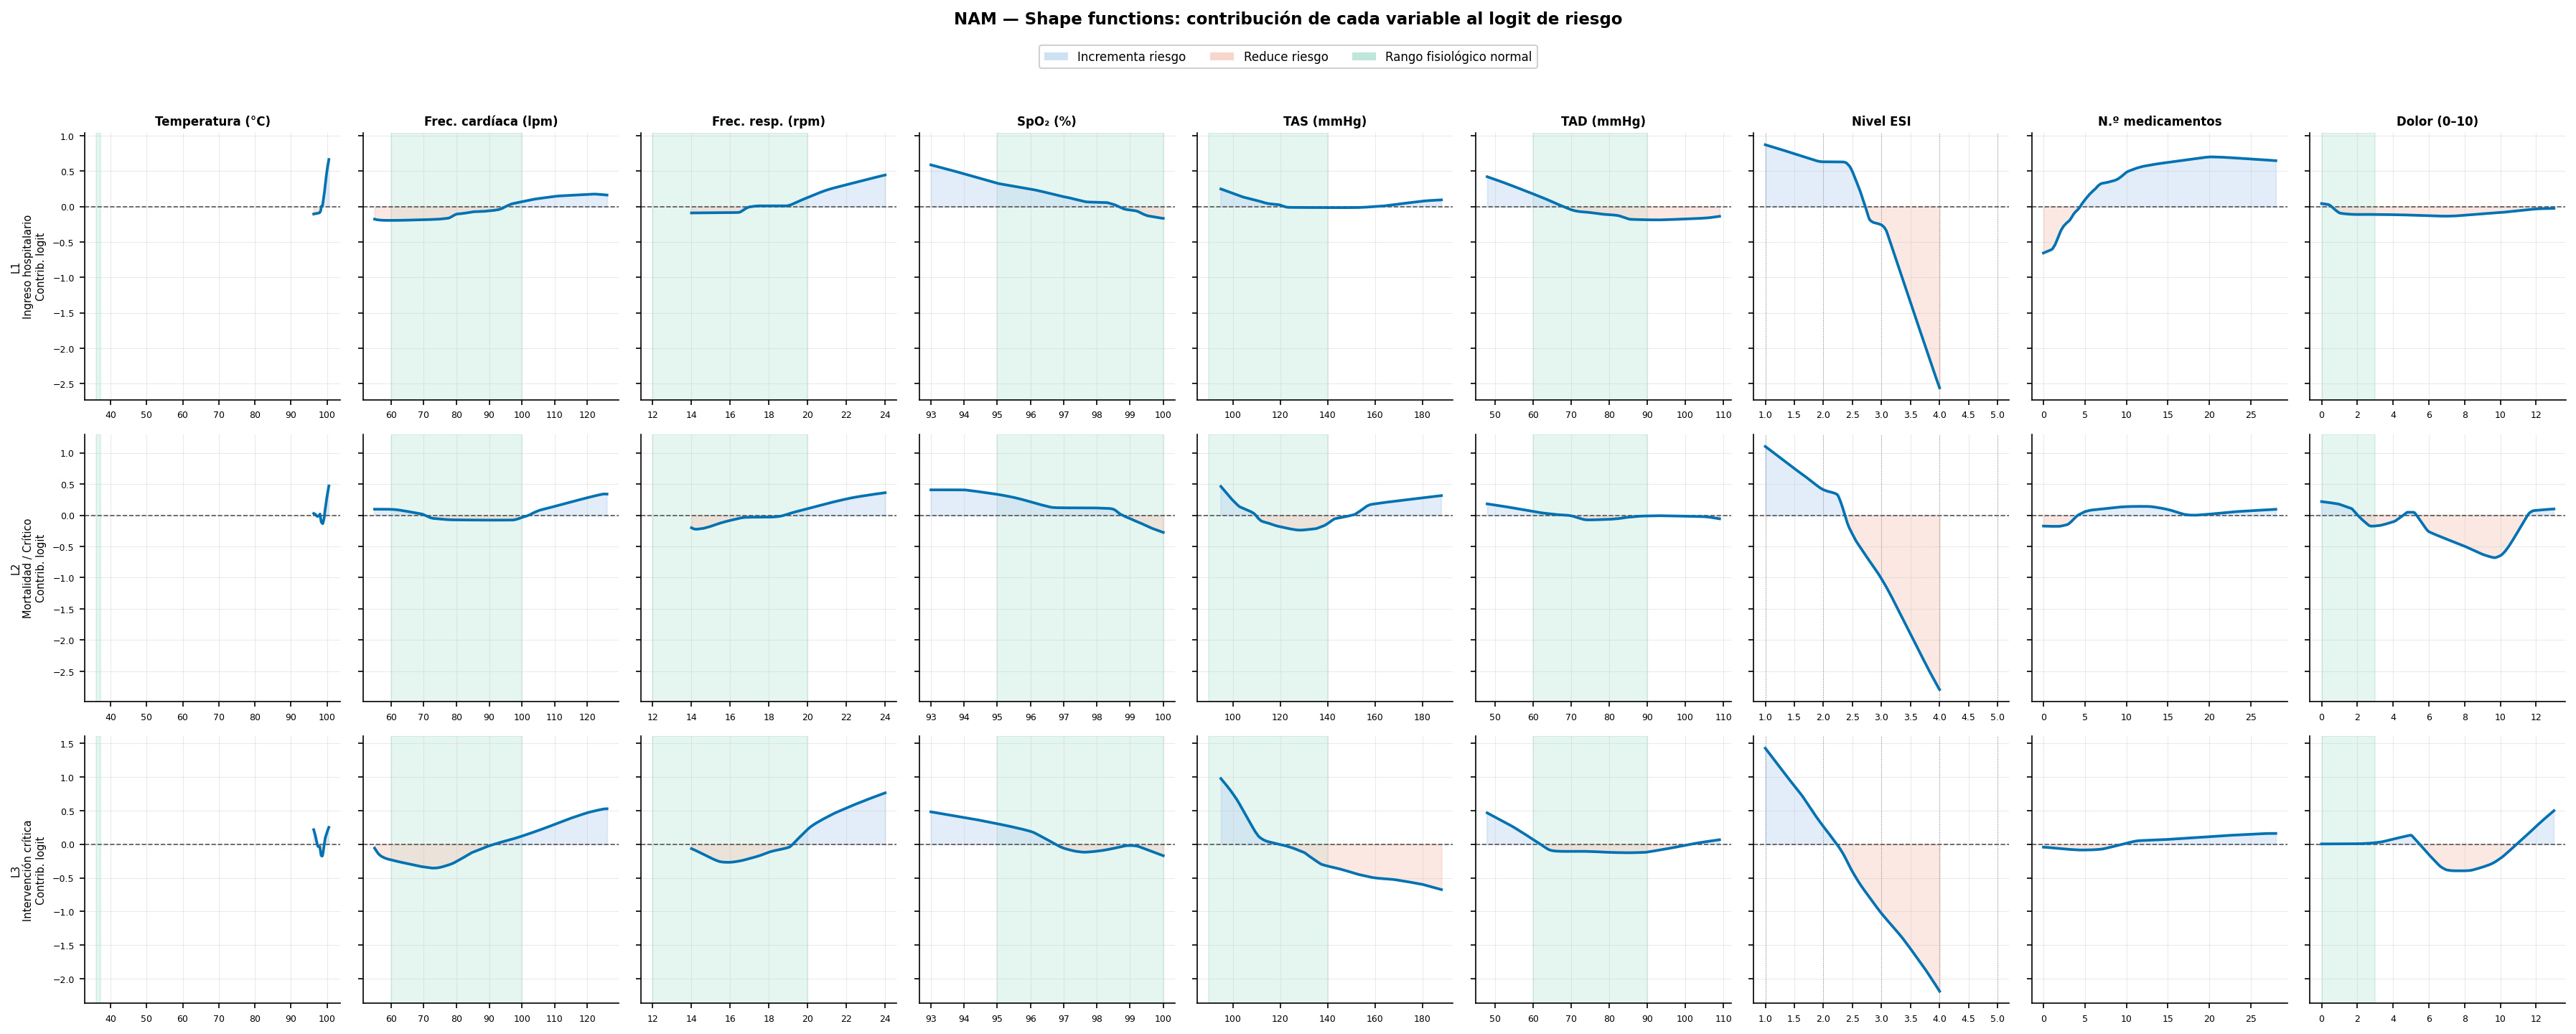

nam_shape_functions.png guardado (300 dpi)


In [8]:
fig, axes = plt.subplots(3, 9, figsize=(24, 9), sharey='row')
fig.patch.set_facecolor('white')

for row, t in enumerate(TARGETS):
    m = models[t]
    for col, feat in enumerate(FEATURES):
        ax = axes[row, col]
        ax.set_facecolor('white')
        fi = FEAT_IDX[feat]  # índice de la feature en NAM_FEATS (modelo tiene 11 features)
        orig, contrib = compute_shape(m, fi, X_scaled[:, fi])

        # Sombreado positivo (incrementa riesgo) y negativo (reduce riesgo)
        ax.fill_between(orig, contrib, 0,
                        where=(contrib >= 0), alpha=0.40, color=FILL_P, zorder=1)
        ax.fill_between(orig, contrib, 0,
                        where=(contrib < 0),  alpha=0.40, color=FILL_N, zorder=1)

        # Banda de rango fisiológico normal
        if NORMAL_RANGES[feat] is not None:
            lo, hi = NORMAL_RANGES[feat]
            ax.axvspan(lo, hi, alpha=0.10, color=GREEN, zorder=0)

        # Línea de referencia en 0
        ax.axhline(0, color=ZERO_C, lw=0.8, ls='--', zorder=2)

        # Shape function
        ax.plot(orig, contrib, color=BLUE, lw=1.8, zorder=3)

        # Acuity: marcar niveles ESI discretos (1–5)
        if feat == 'acuity':
            for v in [1, 2, 3, 4, 5]:
                ax.axvline(v, color='gray', lw=0.5, ls=':', alpha=0.8)

        # Etiquetas
        if row == 0:
            ax.set_title(FEAT_LABELS[feat], fontsize=8, fontweight='bold', pad=5)
        if col == 0:
            ax.set_ylabel(f'{t}\n{TARGET_NAMES[t]}\nContrib. logit', fontsize=7)

        ax.tick_params(axis='both', labelsize=6)

# Leyenda global
legend_patches = [
    mpatches.Patch(facecolor=FILL_P, alpha=0.7, label='Incrementa riesgo'),
    mpatches.Patch(facecolor=FILL_N, alpha=0.7, label='Reduce riesgo'),
    mpatches.Patch(facecolor=GREEN,  alpha=0.25, label='Rango fisiológico normal'),
]
fig.legend(handles=legend_patches, loc='upper center', fontsize=8,
           framealpha=0.9, edgecolor='#cccccc', ncol=3,
           bbox_to_anchor=(0.5, 1.03))

plt.suptitle(
    'NAM — Shape functions: contribución de cada variable al logit de riesgo',
    fontsize=11, fontweight='bold', y=1.06
)
plt.tight_layout()
plt.savefig(FIG / 'nam_shape_functions.png', dpi=300, bbox_inches='tight')
plt.show()
print('nam_shape_functions.png guardado (300 dpi)')

## 8. Figuras individuales por target (2×4, para el paper)

Una figura 2×4 por target con mayor resolución y etiquetas de eje más legibles. Formato adecuado para figuras suplementarias del manuscrito (300 dpi).

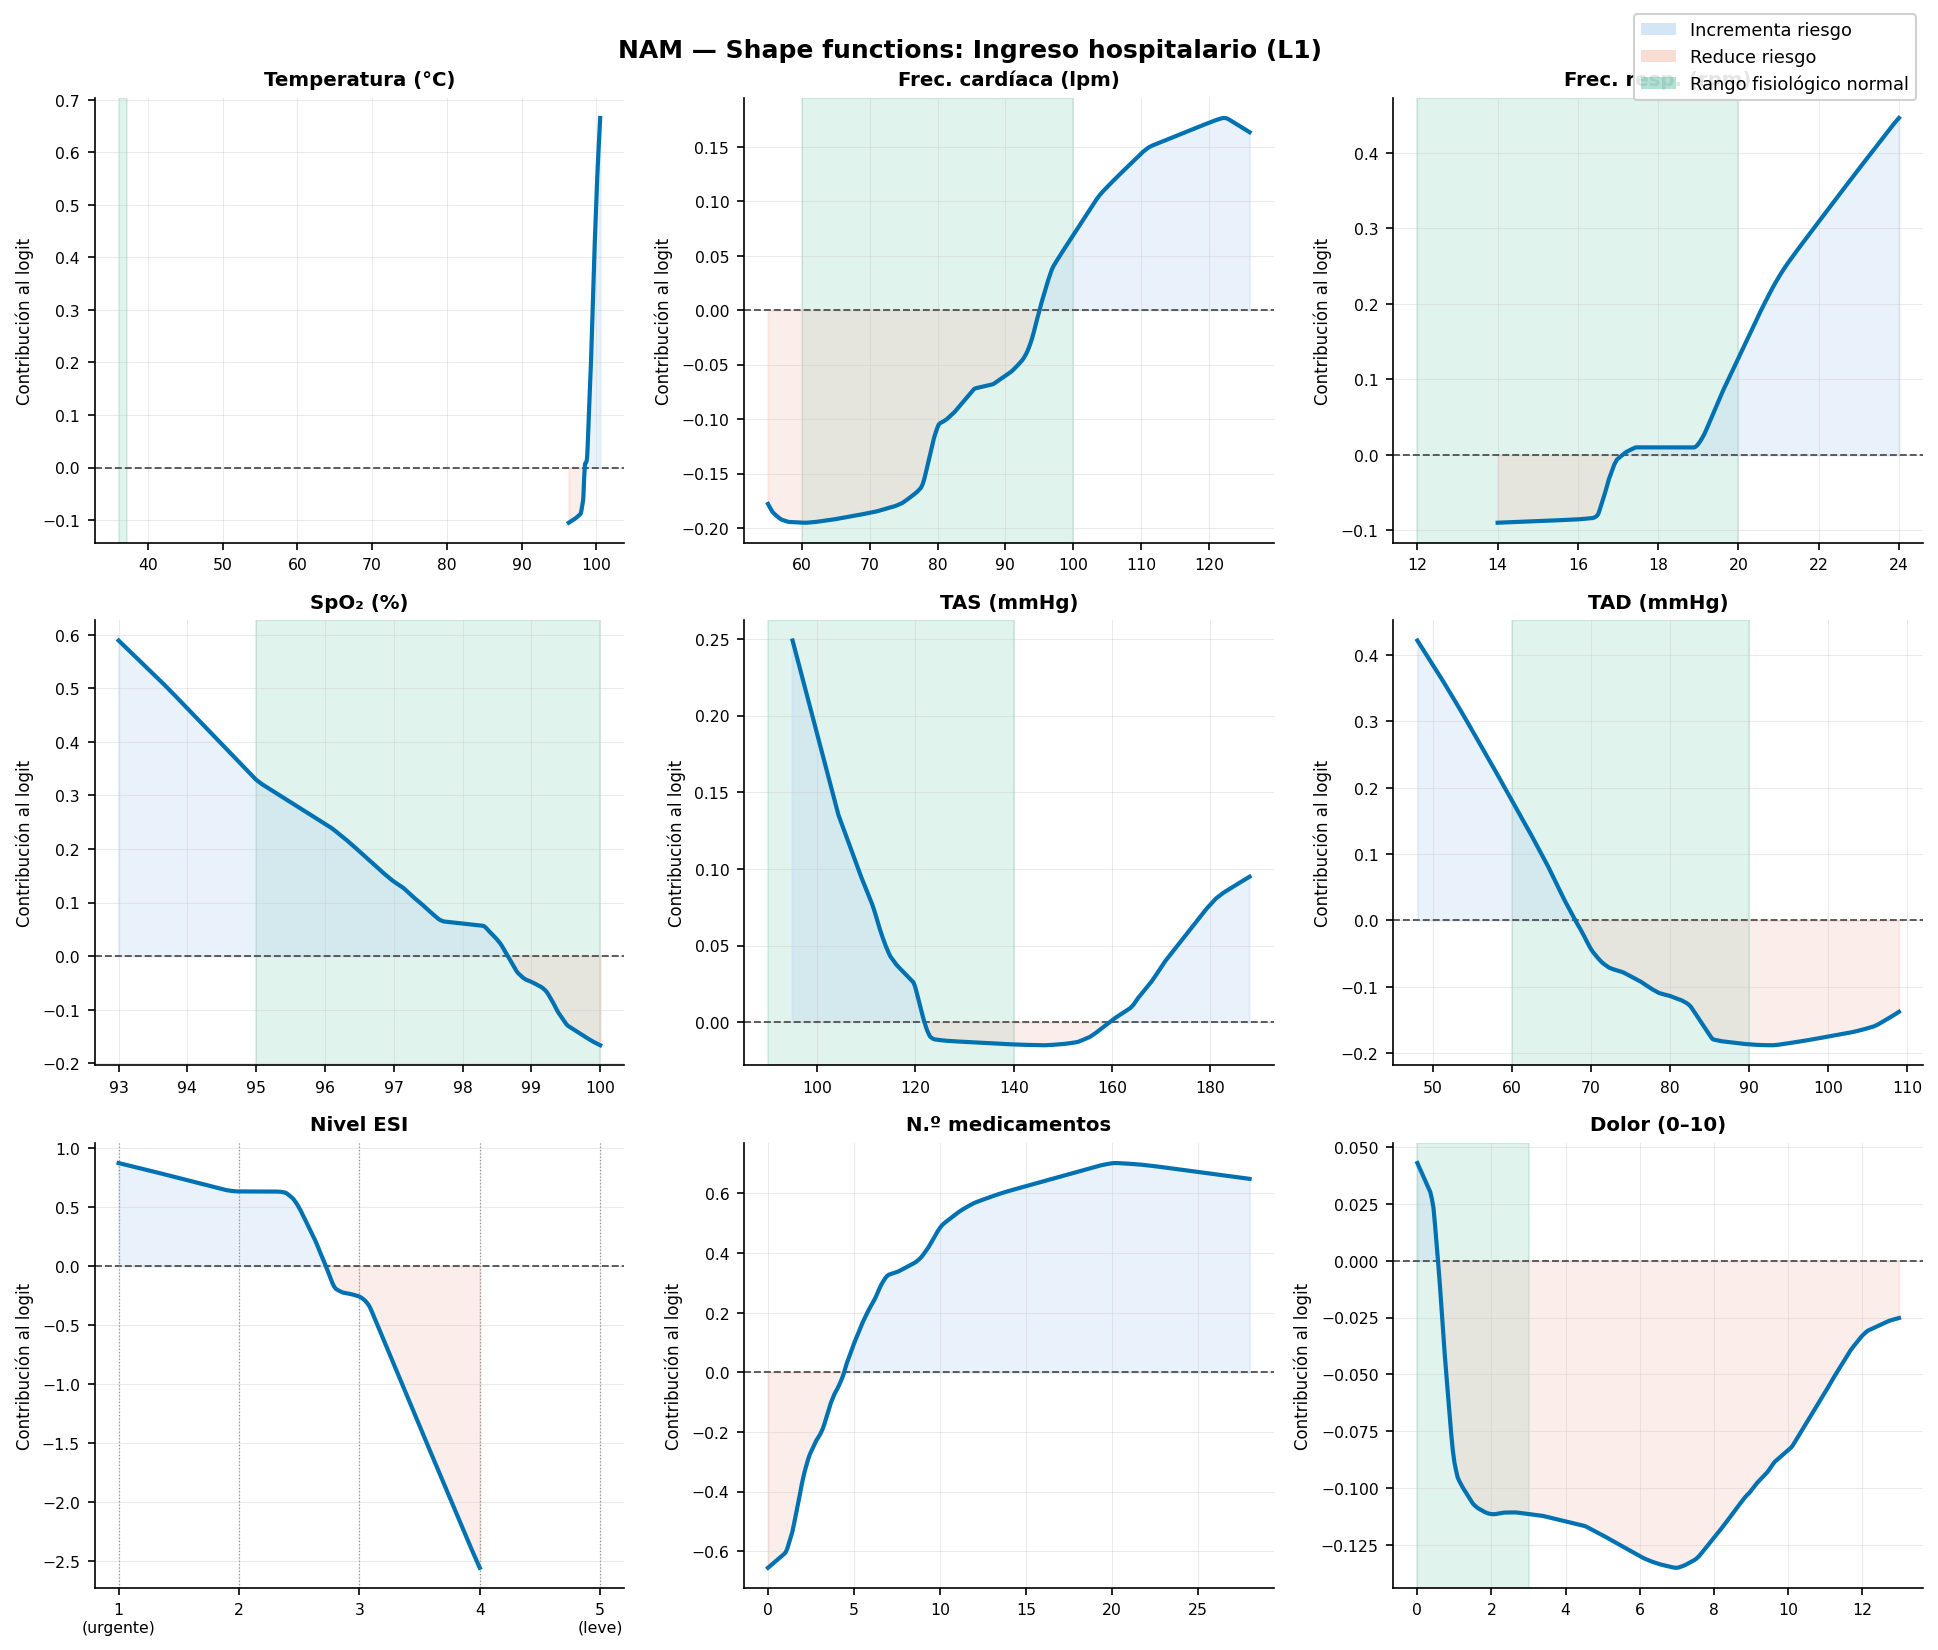

nam_shape_L1.png guardado (300 dpi)


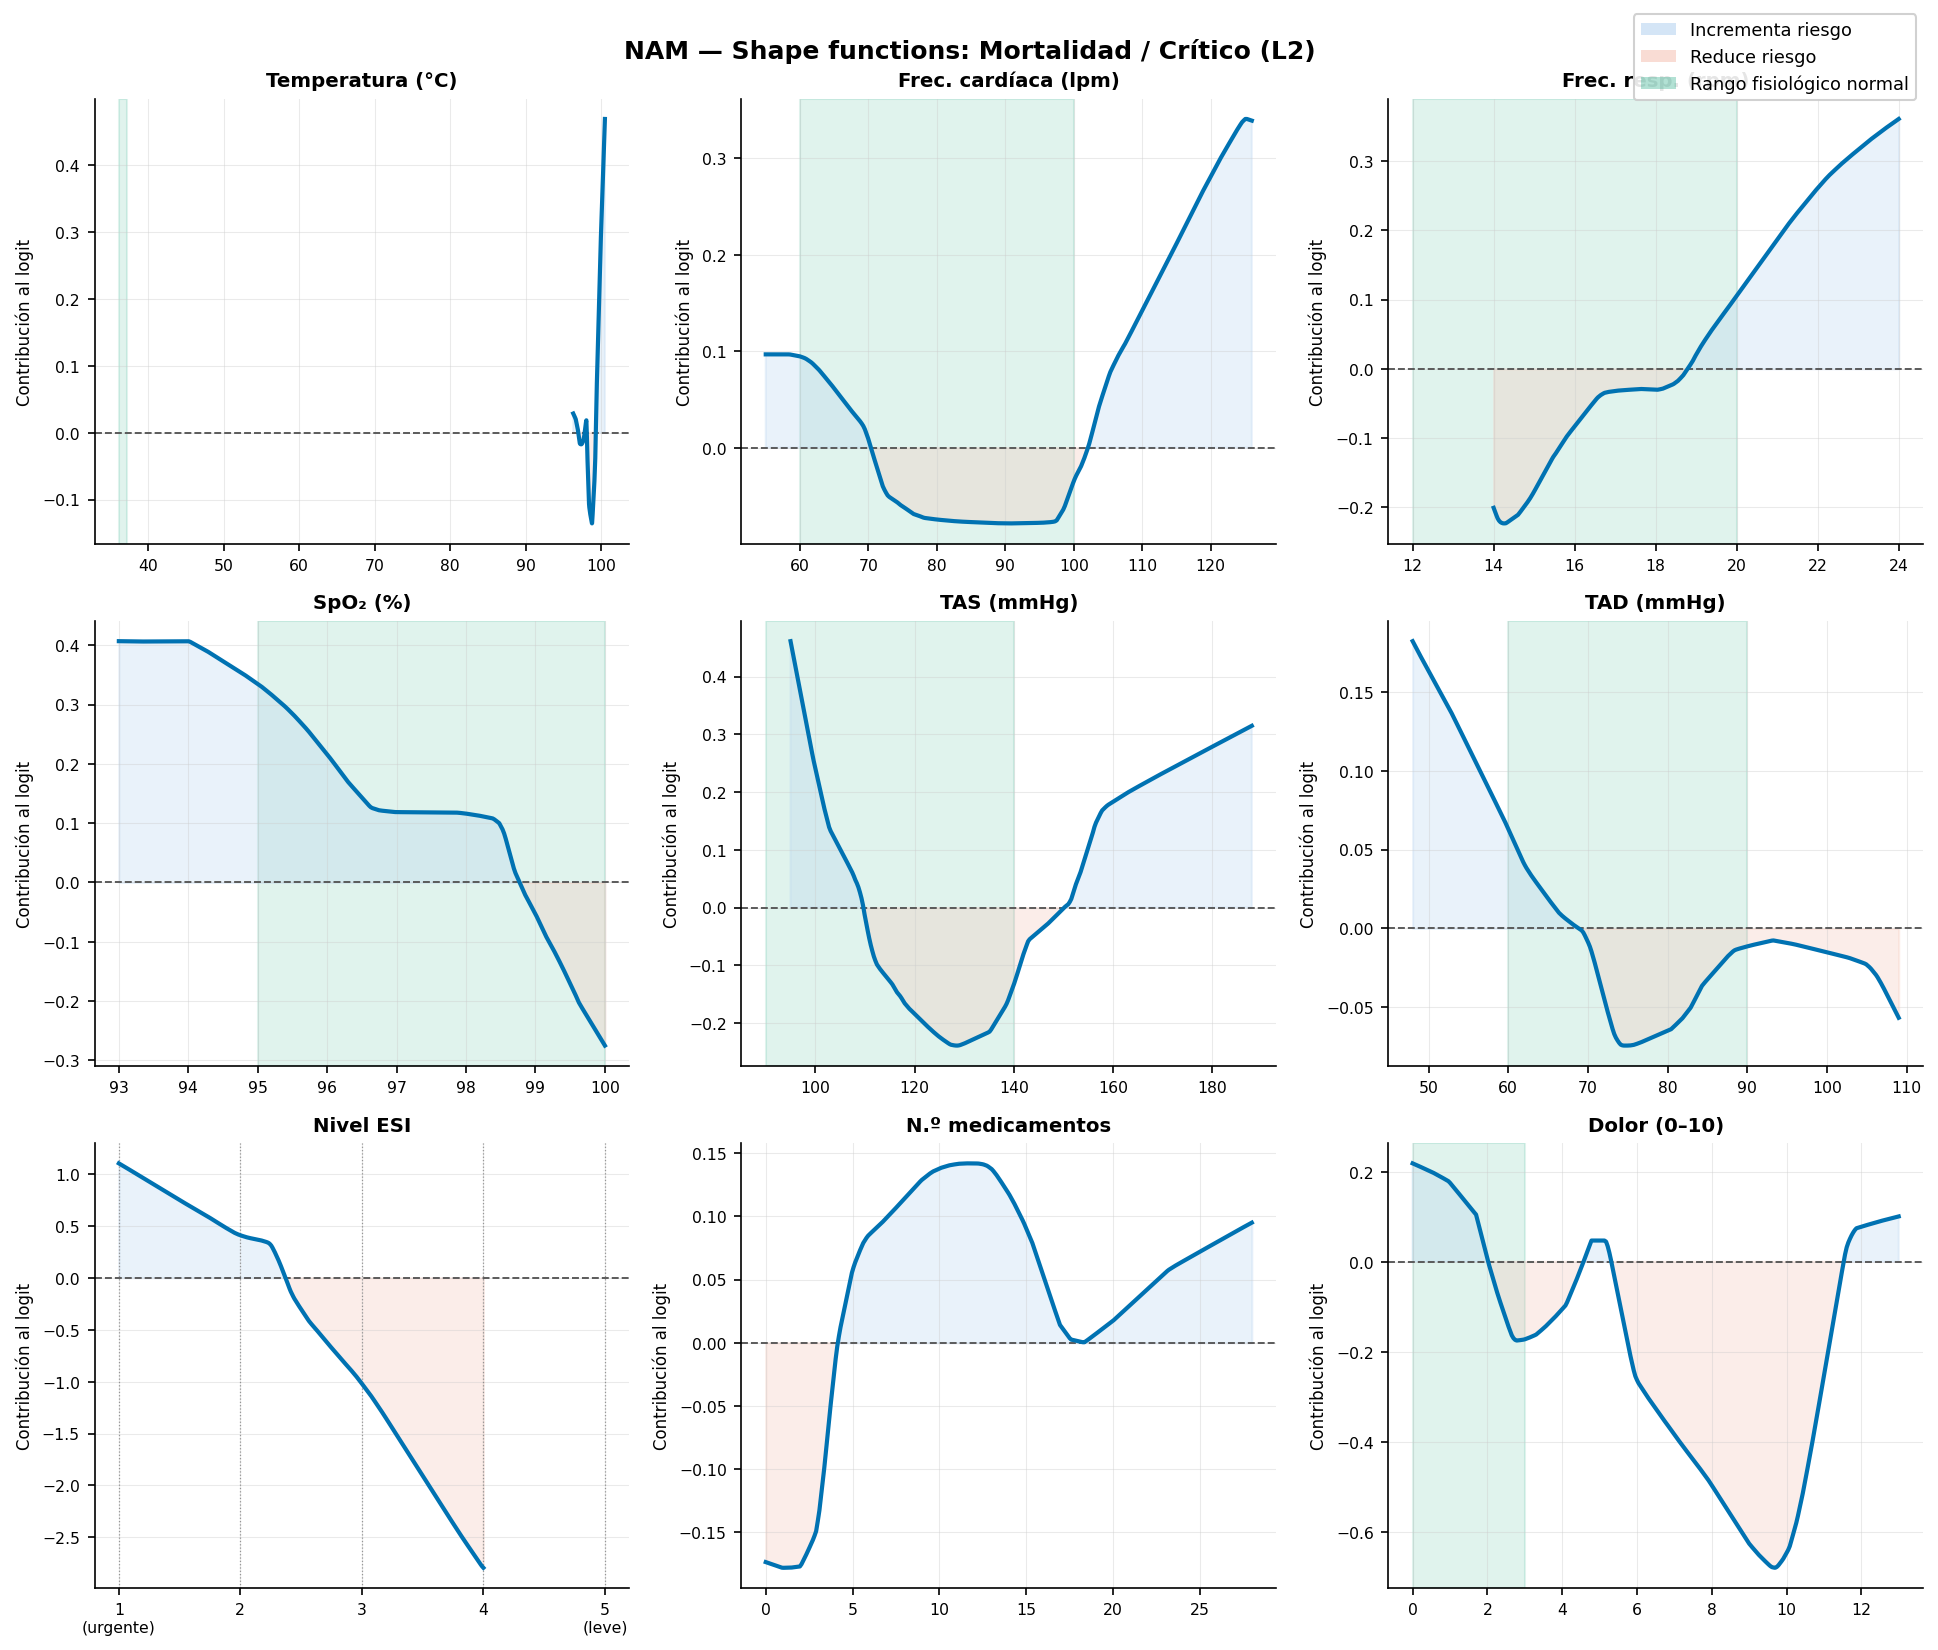

nam_shape_L2.png guardado (300 dpi)


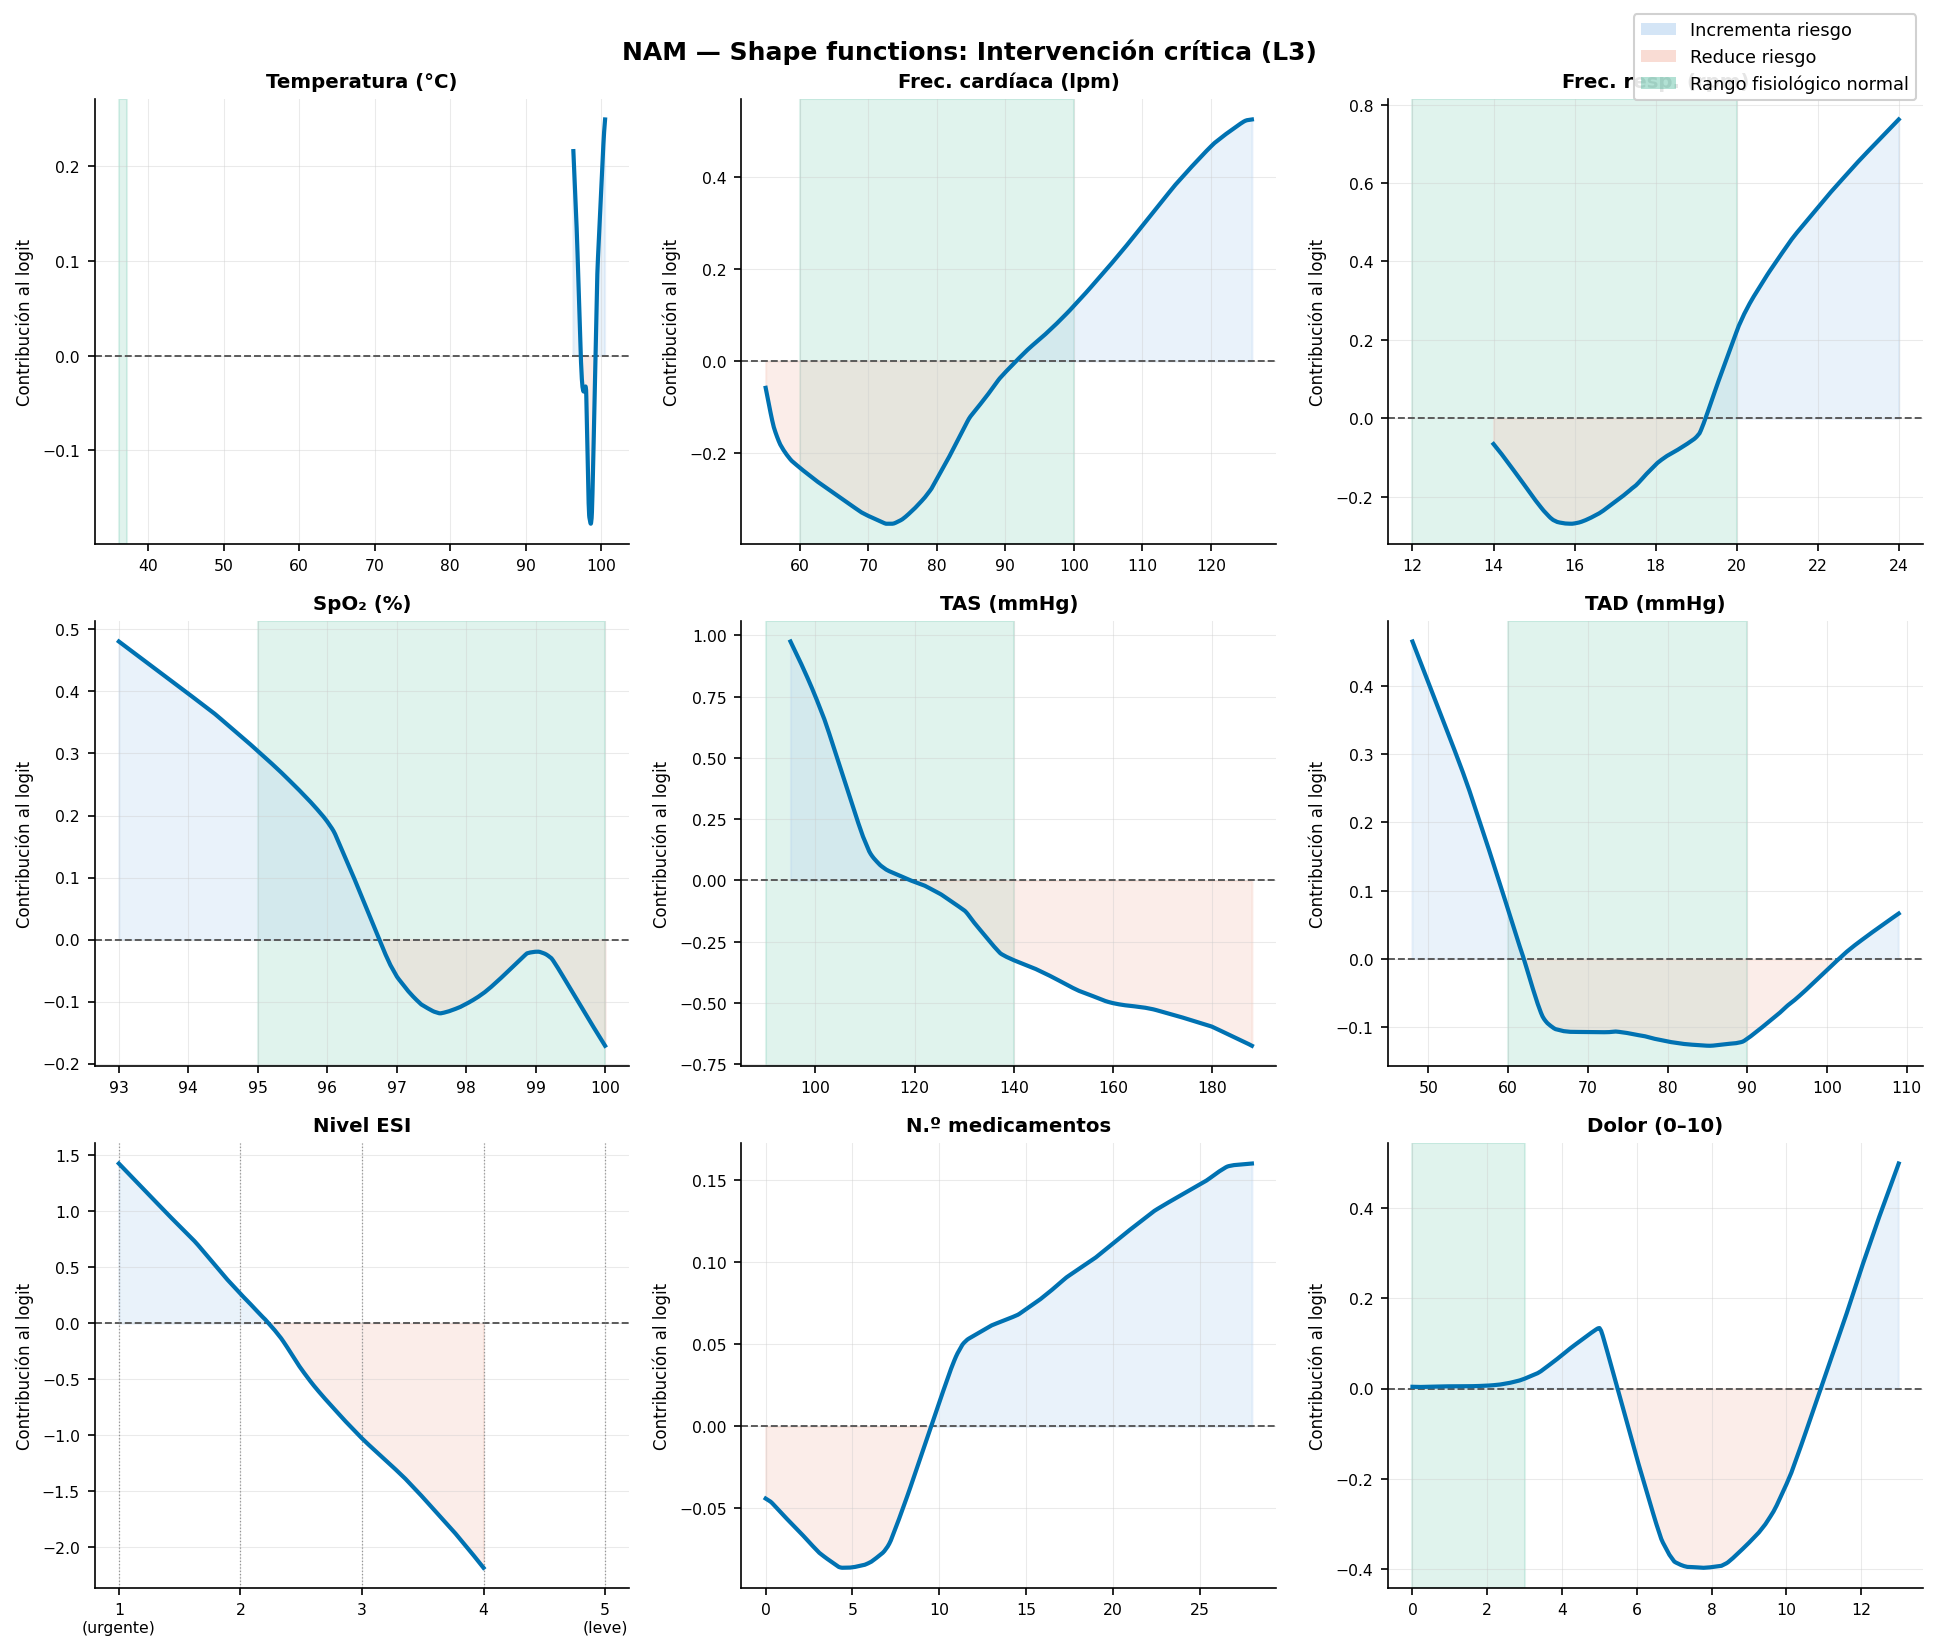

nam_shape_L3.png guardado (300 dpi)


In [9]:
for t in TARGETS:
    m = models[t]
    fig, axes = plt.subplots(3, 3, figsize=(13, 11))
    fig.patch.set_facecolor('white')
    axes_flat = axes.flatten()
    for _ax in axes_flat:
        _ax.set_facecolor('white')

    for col, feat in enumerate(FEATURES):
        ax = axes_flat[col]
        fi = FEAT_IDX[feat]  # índice en NAM_FEATS
        orig, contrib = compute_shape(m, fi, X_scaled[:, fi])

        ax.fill_between(orig, contrib, 0,
                        where=(contrib >= 0), alpha=0.30, color=FILL_P, zorder=1)
        ax.fill_between(orig, contrib, 0,
                        where=(contrib < 0),  alpha=0.30, color=FILL_N, zorder=1)

        if NORMAL_RANGES[feat] is not None:
            lo, hi = NORMAL_RANGES[feat]
            ax.axvspan(lo, hi, alpha=0.12, color=GREEN, zorder=0, label='Rango normal')

        ax.axhline(0, color=ZERO_C, lw=0.9, ls='--', zorder=2)
        ax.plot(orig, contrib, color=BLUE, lw=2.0, zorder=3)

        if feat == 'acuity':
            for v in [1, 2, 3, 4, 5]:
                ax.axvline(v, color='gray', lw=0.6, ls=':', alpha=0.8)
            ax.set_xticks([1, 2, 3, 4, 5])
            ax.set_xticklabels(['1\n(urgente)', '2', '3', '4', '5\n(leve)'], fontsize=6.5)

        ax.set_title(FEAT_LABELS[feat], fontsize=9.5, fontweight='bold')
        ax.set_ylabel('Contribución al logit', fontsize=8)
        ax.tick_params(labelsize=7.5)

    legend_patches = [
        mpatches.Patch(facecolor=FILL_P, alpha=0.6, label='Incrementa riesgo'),
        mpatches.Patch(facecolor=FILL_N, alpha=0.6, label='Reduce riesgo'),
        mpatches.Patch(facecolor=GREEN,  alpha=0.30, label='Rango fisiológico normal'),
    ]
    fig.legend(handles=legend_patches, loc='upper right', fontsize=8.5,
               framealpha=0.9, edgecolor='#cccccc',
               bbox_to_anchor=(0.99, 1.00))

    plt.suptitle(
        f'NAM — Shape functions: {TARGET_NAMES[t]} ({t})',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    fname = FIG / f'nam_shape_{t}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'{fname.name} guardado (300 dpi)')

## 9. Tabla resumen: rango y monotonía de cada shape function

Para cada feature y target: contribución mínima y máxima al logit, rango total y dirección de monotonía estimada mediante correlación de Spearman. Permite verificar la coherencia clínica de las shape functions de forma sistemática.

In [10]:
from IPython.display import display
from scipy.stats import spearmanr

rows = []
for t in TARGETS:
    m = models[t]
    for feat in FEATURES:
        fi = FEAT_IDX[feat]
        orig, contrib = compute_shape(m, fi, X_scaled[:, fi], n_points=500)
        rng = contrib.max() - contrib.min()
        rho, _ = spearmanr(orig, contrib)
        if abs(rho) > 0.7:
            mono = f'{"Creciente" if rho > 0 else "Decreciente"} (ρ={rho:.2f})'
        else:
            mono = f'No lineal (ρ={rho:.2f})'
        rows.append({
            'Target' : f'{t} ({TARGET_NAMES[t]})',
            'Feature': FEAT_LABELS[feat],
            'Contrib. mín.': round(float(contrib.min()), 3),
            'Contrib. máx.': round(float(contrib.max()), 3),
            'Rango (max−min)': round(float(rng), 3),
            'Monotonía': mono,
        })

df_summary = pd.DataFrame(rows)
display(df_summary.set_index(['Target', 'Feature']))

Contrib. mín.  Contrib. máx.  \
Target                    Feature                                              
L1 (Ingreso hospitalario) Temperatura (°C)             -0.105          0.665   
                          Frec. cardíaca (lpm)         -0.195          0.176   
                          Frec. resp. (rpm)            -0.090          0.446   
                          SpO₂ (%)                     -0.167          0.589   
                          TAS (mmHg)                   -0.015          0.249   
                          TAD (mmHg)                   -0.188          0.422   
                          Nivel ESI                    -2.561          0.874   
                          N.º medicamentos             -0.656          0.702   
                          Dolor (0–10)                 -0.135          0.043   
L2 (Mortalidad / Crítico) Temperatura (°C)             -0.136          0.470   
                          Frec. cardíaca (lpm)         -0.078          0.341   
                          Frec. resp. (rpm)            -0.223          0.361   
                          SpO₂ (%)                     -0.275          0.407   
                          TAS (mmHg)                   -0.239          0.461   
                          TAD (mmHg)                   -0.074          0.182   
                          Nivel ESI                    -2.793          1.102   
                          N.º medicamentos             -0.178          0.142   
                          Dolor (0–10)                 -0.680          0.219   
L3 (Intervención crítica) Temperatura (°C)             -0.178          0.250   
                          Frec. cardíaca (lpm)         -0.355          0.526   
                          Frec. resp. (rpm)            -0.269          0.762   
                          SpO₂ (%)                     -0.171          0.481   
                          TAS (mmHg)                   -0.675          0.975   
                          TAD (mmHg)                   -0.127          0.465   
                          Nivel ESI                    -2.185          1.426   
                          N.º medicamentos             -0.086          0.160   
                          Dolor (0–10)                 -0.396          0.498   

                                                Rango (max−min)  \
Target                    Feature                                 
L1 (Ingreso hospitalario) Temperatura (°C)                0.770   
                          Frec. cardíaca (lpm)            0.371   
                          Frec. resp. (rpm)               0.536   
                          SpO₂ (%)                        0.756   
                          TAS (mmHg)                      0.264   
                          TAD (mmHg)                      0.610   
                          Nivel ESI                       3.434   
                          N.º medicamentos                1.358   
                          Dolor (0–10)                    0.178   
L2 (Mortalidad / Crítico) Temperatura (°C)                0.605   
                          Frec. cardíaca (lpm)            0.419   
                          Frec. resp. (rpm)               0.584   
                          SpO₂ (%)                        0.682   
                          TAS (mmHg)                      0.700   
                          TAD (mmHg)                      0.256   
                          Nivel ESI                       3.895   
                          N.º medicamentos                0.320   
                          Dolor (0–10)                    0.898   
L3 (Intervención crítica) Temperatura (°C)                0.427   
                          Frec. cardíaca (lpm)            0.881   
                          Frec. resp. (rpm)               1.032   
                          SpO₂ (%)                        0.652   
                          TAS (mmHg)                      1.650   
                          TAD (mmHg)                

## 10. Interpretacion clinica esperada

| Feature | Comportamiento esperado | Mecanismo clínico |
|---------|------------------------|-------------------|
| SpO₂ | **Decreciente**: valores bajos → mayor riesgo | Hipoxemia → fallo respiratorio / shock |
| TAS | **U-shape o decreciente**: hipotensión → mayor riesgo | Hipoperfusión tisular / shock |
| Frec. cardíaca | **No lineal**: taquicardia y bradicardia extremas → riesgo | Respuesta compensatoria / fallo bomba |
| Frec. resp. | **Creciente**: taquipnea → mayor riesgo | Distrés respiratorio |
| Temperatura | **U-shape**: hipotermia e hipertermia → riesgo | Sepsis (fiebre) y shock avanzado (hipotermia) |
| Acuity ESI | **Fuertemente decreciente**: ESI=1 (urgente) → mayor riesgo | El triajista ya captura la gravedad |
| N.º medicamentos | **Creciente**: polyfarmacia → mayor riesgo basal | Multimorbilidad / fragilidad |
| TAD | **Decreciente o U**: TAD baja → hipoperfusión diastólica | Presión de perfusión coronaria reducida |

> **Nota de cautela:** las shape functions muestran el efecto *marginal* de cada variable, asumiendo
> las demás constantes. Dado que las variables clínicas están correlacionadas (p. ej., FC y TA
> en shock), los efectos individuales pueden parecer atenuados. Usar en conjunción con SHAP para
> interpretación conjunta.